<a href="https://colab.research.google.com/github/LuxTenebriis/Mrk71_SED/blob/main/Lux_Mrk71_SED_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ★ Mrk71 Stellar Energy Distribution Plots ★

☆ last updated: 10/10/2026
<br>
<br>
LAYOUT☆☆☆<br>
Setup ⟶ import all packagaes, set path directories and define photometry columns <br>
Functions ⟶  implement the standarised functions for data processing (aka "cleaning" the columns) and plotting the diagrams
<br><br>
Knot A ⟶ calls the functions for analysis of knot A <br>
Knot B ⟶ calls the functions for analysis of knot B <br>
Region II ⟶ calls the functions for analysis of region ii <br>
<br><br>
☆ U-M GPT was used to assist with Python syntax, code organization, debugging, and editing.

---



## ★ SETUP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

In [ ]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#set up paths
main_path= Path("/content/drive/MyDrive/★ Research/Unresolved Binaries")
data_path = main_path / "Data/Mrk71_Data/Paper Photometry Tables"
knotA_path = data_path / "KnotA_Photometry.csv"
knotB_path = data_path / "KnotB_Photometry.csv"
regionII_path = data_path / "RegII_Photometry.csv"
output_path= main_path / "Outputs/SED/Mrk71"

In [ ]:
#define column names
magnitude_cols = ["F150LP","F165LP","F336W","F438W", "F547M","F814W"]
error_cols = ["F150LP_mags_err", "F165LP_mags_err", "F336W_mags_err", "F438W_mags_err", "F547M_mags_err","F814W_mags_err"]
#LUX note: I'm not sure if this is accurate, what I am doing is converting the
# filters (in A into nm using a angstrom to nm calculator)
wavelengths = np.array([
    161.1,  # F150LP
    175.8,  # F165LP
    335.5,  # F336W
    432.5,  # F438W
    544.7,  # F547M
    802.4   # F814W
])



---



## ★ FUNCTIONS

In [ ]:
#read in and "clean up" tables
def prepare_table(file_path, region_name):

  #read file
  table_raw = pd.read_csv(file_path)
  table = table_raw.copy()

  #EDITS ★ only keep: type of star, filters, corresponding marg error cols
  #aka remove the unamed column, and the position (x,y) columns
  table = table.drop(columns=["Unnamed: 0", "x", "y"], errors="ignore")

  #convert to numeric values for later plotting
  #converts nonnumeric entries into "n/a"
  for col in magnitude_cols + error_cols:
    table[col] = pd.to_numeric(table[col], errors='coerce')

  #round numerical values to 2 decimal points
  table[magnitude_cols]= table[magnitude_cols].round(2)
  table[error_cols]= table[error_cols].round(2)

  #delete the stars with missing magnitudes + error data
  #(only keep ones with data in all six filters + their corresponding error cols)
  table_six = table.dropna(subset=magnitude_cols).copy()
  table_six = table.dropna(subset=error_cols).copy()

  return table_raw, table, table_six


In [ ]:
#Make separate tables for each type of star (aka MS, RSG, Y/R)
def separate_star_types(table):
  table_YR = table[table["Label"] == "Y/R"].copy()
  table_MS = table[table["Label"] == "MS"].copy()
  table_RSG = table[table["Label"] == "RSG"].copy()

  return table_YR, table_MS, table_RSG

In [ ]:
def display_stats(
    table_raw,table, table_six,
    table_YR, table_MS, table_RSG,
    table_six_YR, table_six_MS, table_six_RSG
):

  print("Raw Table:")
  display(table_raw)
  print("Clean Table — All Available Data:")
  display(table)
  print("Clean Table (only displaying stars with ALL six filters):")
  display(table_six)

  print("Final Column Names:", table.columns)
  print("Initial Star Numer:", len(table_raw))
  print("Filtered Stars:", (len(table_raw)-len(table_six)))
  print("Final Stars:", len(table_six))

  print("")
  print("ALL MS Stars", len(table_MS))
  print("ALL RSG Stars", len(table_RSG))
  print("ALL YR Stars", len(table_YR))

  print("")
  print("ALL MS Stars:")
  display(table_MS)
  print("ALL RSG Stars:")
  display(table_RSG)
  print("ALL YR Stars:")
  display(table_YR)

  print("")
  print("Clean MS Stars:", len(table_six_MS))
  print("Clean RSG Stars:", len(table_six_RSG))
  print("Clean YR Stars:", len(table_six_YR))

  print("")
  print("Clean MS Stars:")
  display(table_six_MS)
  print("Clean RSG Stars:")
  display(table_six_RSG)
  print("Clean YR Stars:")
  display(table_six_YR)

  return

☆☆ plot SED

In [ ]:
def plot_sed_grid(knotA, knotB, regionII, filename):

    regions = [("Knot A", knotA), ("Knot B", knotB), ("Region II", regionII)]
    star_types = ["Y/R", "MS", "RSG", "Combined"]

    colors = {
        "MS": ("cornflowerblue", 0.15),
        "Y/R": ("goldenrod", 0.55),
        "RSG": ("crimson", 0.55)
    }

    fig, axes = plt.subplots(3, 4, figsize=(12, 11), sharey=True)

    for row, (region_name, table) in enumerate(regions):

        for col, star_type in enumerate(star_types):
            ax = axes[row, col]

            subset = (
                table if star_type == "Combined"
                else table[table["Label"] == star_type]
            )

            for _, star in subset.iterrows():

                color, alpha = colors.get(
                    star["Label"], ("gray", 0.4)
                )

                magnitudes = star[magnitude_cols].to_numpy(float)
                errors = star[error_cols].to_numpy(float)

                valid = np.isfinite(magnitudes)
                valid_errors = valid & np.isfinite(errors)

                ax.scatter(
                    wavelengths[valid],
                    magnitudes[valid],
                    color=color,
                    alpha=alpha,
                    s=10
                )

                ax.errorbar(
                    wavelengths[valid_errors],
                    magnitudes[valid_errors],
                    yerr=errors[valid_errors],
                    color=color,
                    alpha=alpha,
                    linestyle="none",
                    capsize=1
                )

              #

            ax.set_xticks(wavelengths)
            ax.set_xticklabels(magnitude_cols, rotation=90, fontsize=7)
            ax.tick_params(axis="y", labelsize=8)
            ax.set_xlabel("Filter", fontsize=9)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(False)

            if row == 0:
                ax.set_title(star_type, fontsize=11, fontweight="bold")

            if col == 0:
                ax.set_ylabel(
                    f"{region_name}\nMagnitude",
                    fontsize=10,
                    fontweight="bold"
                )

    # Invert the shared magnitude axis once
    axes[0, 0].invert_yaxis()

    legend_handles = [
        Line2D([], [], marker="o", linestyle="none",
               color="goldenrod", label="Y/R"),
        Line2D([], [], marker="o", linestyle="none",
               color="cornflowerblue", label="MS"),
        Line2D([], [], marker="o", linestyle="none",
               color="crimson", label="RSG")
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper right",
        frameon=False
    )

    fig.suptitle(
        "Stellar Magnitude Distributions",
        fontsize=16,
        fontweight="bold"
    )

    plt.subplots_adjust(
        left=0.10,
        right=0.92,
        top=0.90,
        bottom=0.10,
        wspace=0.35,
        hspace=0.55
    )

    figure_path = Path(output_path) / filename
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [ ]:
# Plot magnitude versus filter for a table of stars
# Complete stars are connected with lines; incomplete stars are points only

def plot_sed(star_table, region_name, star_type, filename):

    plt.figure(figsize=(8, 8))

    for _, star in star_table.iterrows():

        colors = {
            "MS": ("cornflowerblue", 0.1),
            "Y/R": ("goldenrod", 0.4),
            "RSG": ("crimson", 0.4)
        }

        color, alpha = colors.get(star["Label"], ("gray", 0.4))

        magnitudes = star[magnitude_cols].to_numpy(float)
        errors = star[error_cols].to_numpy(float)

        valid = np.isfinite(magnitudes)
        valid_errors = valid & np.isfinite(errors)

        # Plot every available point
        plt.scatter(
            wavelengths[valid],
            magnitudes[valid],
            s=20,
            color=color,
            alpha=alpha
        )

        # Plot available error bars
        plt.errorbar(
            wavelengths[valid_errors],
            magnitudes[valid_errors],
            yerr=errors[valid_errors],
            linestyle="none",
            capsize=2,
            color=color,
            alpha=alpha
        )

        # Connect points only if the star has all six filters
        if valid.all():
            plt.plot(
                wavelengths,
                magnitudes,
                color=color,
                alpha=alpha
            )

    ax = plt.gca()

    # Add the key only to combined plots
    if star_type == "Combined":

        key = [
            Line2D(
                [0], [0],
                color="cornflowerblue",
                marker="o",
                linestyle="none",
                label="MS"
            ),
            Line2D(
                [0], [0],
                color="goldenrod",
                marker="o",
                linestyle="none",
                label="Y/R"
            ),
            Line2D(
                [0], [0],
                color="crimson",
                marker="o",
                linestyle="none",
                label="RSG"
            ),
            Line2D(
                [0], [0],
                color="black",
                marker="o",
                linestyle="-",
                label="All 6 filters"
            ),
            Line2D(
                [0], [0],
                color="black",
                marker="o",
                linestyle="none",
                label="Incomplete data"
            )
        ]

        ax.legend(
            handles=key,
            title="",
            loc="upper left",
            bbox_to_anchor=(1.03, 1),
            frameon=False,
            fontsize=10,
            title_fontsize=11
        )

    plt.xticks(
        wavelengths,
        magnitude_cols,
        rotation=90,
        fontsize=10
    )
    plt.yticks(fontsize=10)

    ax.set_ylim(28, 12)
    ax.tick_params(axis="x", pad=10)
    ax.tick_params(axis="y", pad=8)

    plt.xlabel("Filter", fontsize=12, labelpad=18)
    plt.ylabel("Magnitude", fontsize=12, labelpad=18)
    plt.title(
        f"{region_name}: {star_type} Stars",
        fontsize=18,
        pad=45
    )

    plt.grid(alpha=0.25)
    plt.tight_layout()

    figure_path = Path(output_path) / filename
    plt.savefig(figure_path, dpi=600)
    plt.show()
    plt.close()

    return

## ★ KNOT A

In [ ]:
knotA = prepare_table(knotA_path, "Knot A")
knotA_raw, knotA, knotA_six = knotA

# All available-data stars
knotA_YR, knotA_MS, knotA_RSG = separate_star_types(knotA)
# Complete six-filter stars
knotA_six_YR, knotA_six_MS, knotA_six_RSG = separate_star_types(knotA_six)

#☆ Cleaned Tabled Stats (not necessary)
#run if you want to see info about the table edits + new table
display_stats(
    knotA_raw,
    knotA,
    knotA_six,
    knotA_YR,
    knotA_MS,
    knotA_RSG,
    knotA_six_YR,
    knotA_six_MS,
    knotA_six_RSG,
)

Raw Table:


,Unnamed: 0,Label,x,y,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,1,MS,145.290363,6.827725,20.186137,0.013754,20.378016,0.009076,21.587721,0.051084,23.037127,0.041491,23.387957,0.050078,23.533258,0.141568
1,3,MS,128.490631,9.871814,19.802680,0.018183,19.988631,0.018673,21.410785,0.035749,22.926495,0.065575,23.454826,0.061732,23.528241,0.062775
2,4,MS,9.838184,12.950760,19.678734,0.008553,19.871419,0.024352,21.330195,0.018908,22.717907,0.035786,23.161960,0.041356,23.191478,0.043813
3,5,MS,153.570031,13.077751,19.158379,0.012428,19.401226,0.022203,20.728580,0.019966,22.495612,0.022689,22.842227,0.029929,22.604675,0.060435
4,6,MS,103.116329,22.267629,20.342243,0.016194,20.576212,0.035390,22.185725,0.029096,23.735529,0.043433,24.281233,0.081376,24.086686,0.074998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,444,Y/R,32.256052,132.836108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.813302,0.169904,21.276331,0.166163
273,446,Y/R,39.054594,175.134357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.359980,0.140882,22.639274,0.059929
274,452,Y/R,84.608164,345.611495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.774030,0.059604,22.545329,0.014284
275,462,Y/R,2.752790,131.902408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.200353,0.103829,23.940977,0.214259


Clean Table — All Available Data:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,MS,20.19,0.01,20.38,0.01,21.59,0.05,23.04,0.04,23.39,0.05,23.53,0.14
1,MS,19.80,0.02,19.99,0.02,21.41,0.04,22.93,0.07,23.45,0.06,23.53,0.06
2,MS,19.68,0.01,19.87,0.02,21.33,0.02,22.72,0.04,23.16,0.04,23.19,0.04
3,MS,19.16,0.01,19.40,0.02,20.73,0.02,22.50,0.02,22.84,0.03,22.60,0.06
4,MS,20.34,0.02,20.58,0.04,22.19,0.03,23.74,0.04,24.28,0.08,24.09,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.81,0.17,21.28,0.17
273,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.36,0.14,22.64,0.06
274,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.77,0.06,22.55,0.01
275,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.20,0.10,23.94,0.21


Clean Table (only displaying stars with ALL six filters):


...

,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,MS,20.19,0.01,20.38,0.01,21.59,0.05,23.04,0.04,23.39,0.05,23.53,0.14
1,MS,19.80,0.02,19.99,0.02,21.41,0.04,22.93,0.07,23.45,0.06,23.53,0.06
2,MS,19.68,0.01,19.87,0.02,21.33,0.02,22.72,0.04,23.16,0.04,23.19,0.04
3,MS,19.16,0.01,19.40,0.02,20.73,0.02,22.50,0.02,22.84,0.03,22.60,0.06
4,MS,20.34,0.02,20.58,0.04,22.19,0.03,23.74,0.04,24.28,0.08,24.09,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,MS,20.17,0.07,20.22,0.07,21.99,0.08,23.44,0.05,23.54,0.07,23.85,0.10
168,MS,20.11,0.13,20.02,0.15,20.50,0.03,21.69,0.04,21.99,0.04,21.86,0.04
170,MS,19.86,0.02,20.00,0.02,21.71,0.04,23.39,0.04,23.90,0.03,24.06,0.07
172,MS,19.88,0.03,20.05,0.03,21.67,0.03,23.25,0.04,23.90,0.09,24.11,0.04


Clean RSG Stars:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
35,RSG,17.94,0.02,18.22,0.03,20.0,0.01,23.43,0.27,21.58,0.23,22.27,0.02


Clean YR Stars:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
20,Y/R,19.82,0.02,20.05,0.01,21.51,0.04,23.13,0.06,23.58,0.05,23.03,0.10
24,Y/R,20.58,0.07,20.62,0.07,22.29,0.07,23.68,0.09,24.54,0.09,23.95,0.09
26,Y/R,21.04,0.03,20.97,0.06,21.42,0.09,22.67,0.09,23.29,0.06,22.28,0.10
28,Y/R,20.92,0.04,21.09,0.03,21.92,0.05,23.04,0.08,23.61,0.07,22.94,0.09
29,Y/R,19.42,0.05,19.53,0.05,20.25,0.06,21.73,0.06,22.27,0.06,21.56,0.09
47,Y/R,20.73,0.02,20.96,0.03,22.31,0.07,23.64,0.07,24.33,0.07,24.06,0.09
57,Y/R,20.74,0.03,20.90,0.03,22.08,0.05,23.64,0.10,24.56,0.08,23.60,0.11
62,Y/R,19.27,0.11,19.31,0.12,20.93,0.09,22.04,0.06,22.39,0.11,21.35,0.15
68,Y/R,19.30,0.13,19.31,0.12,20.02,0.08,20.99,0.09,21.35,0.13,20.53,0.14
69,Y/R,15.88,0.05,16.00,0.04,16.92,0.04,18.23,0.04,18.64,0.06,18.36,0.06


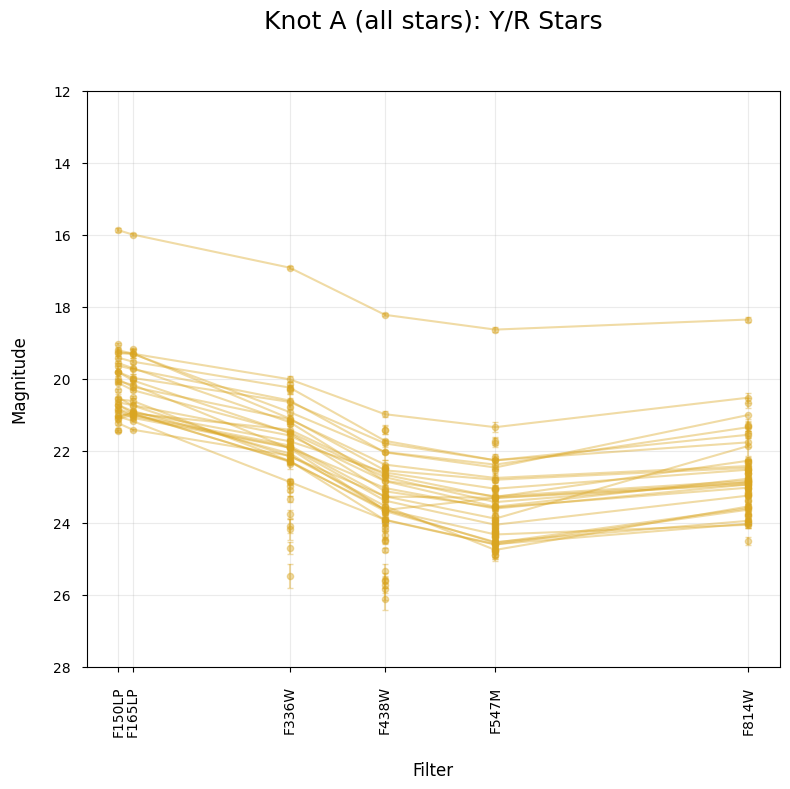

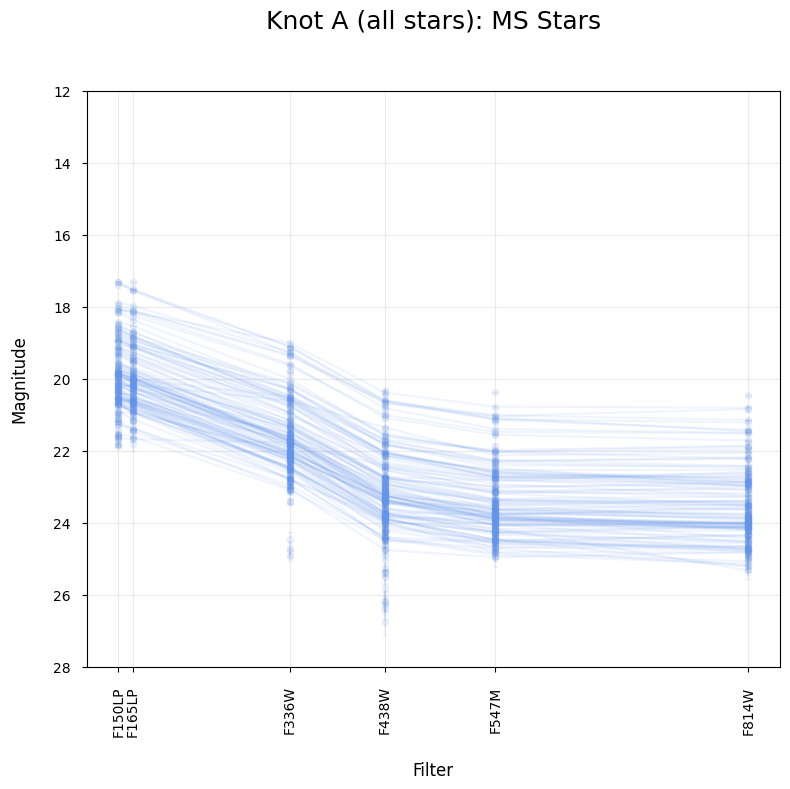

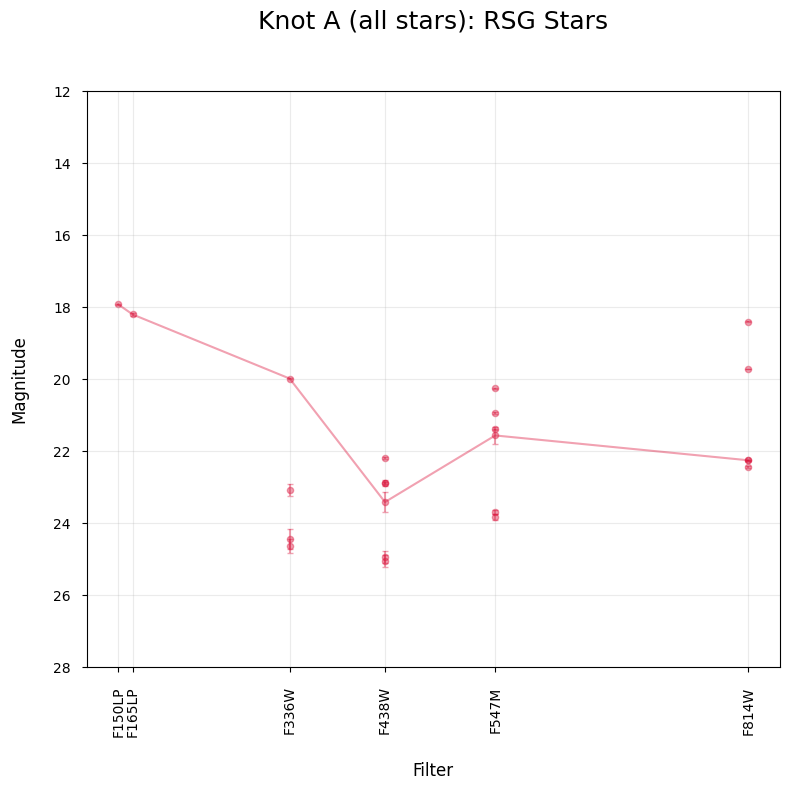

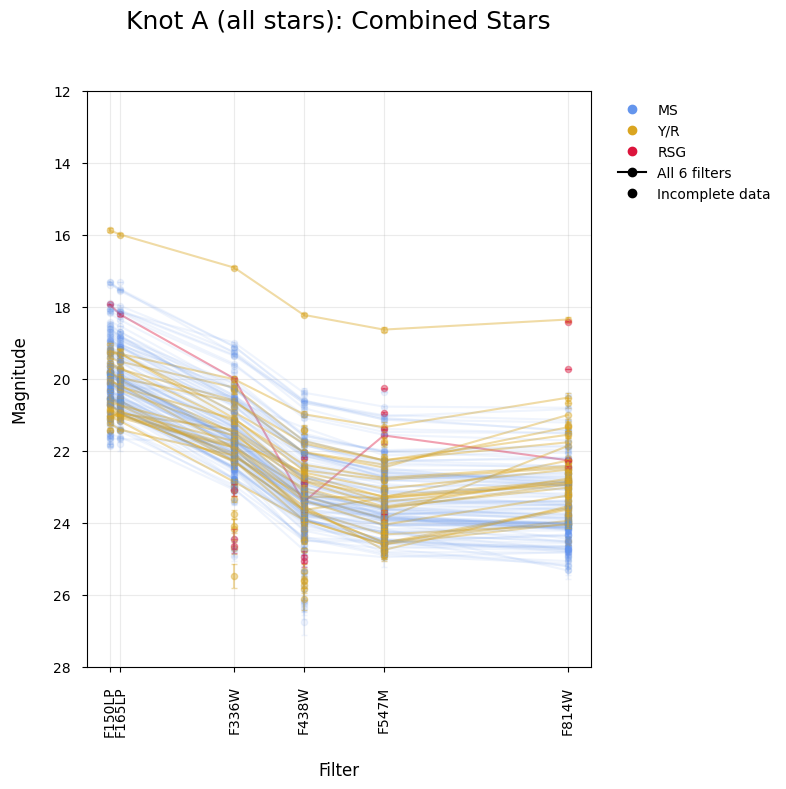

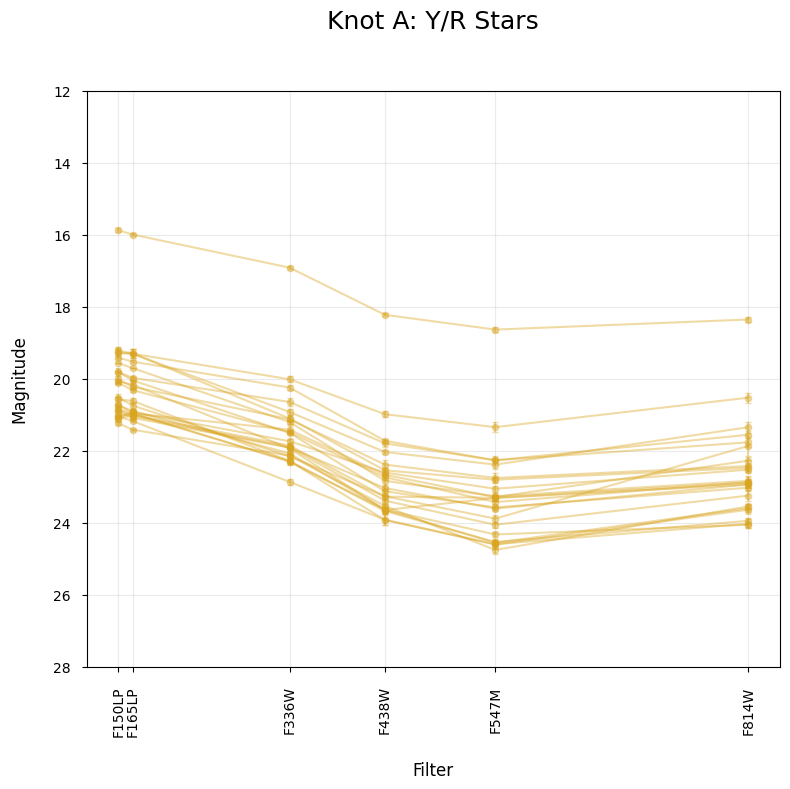

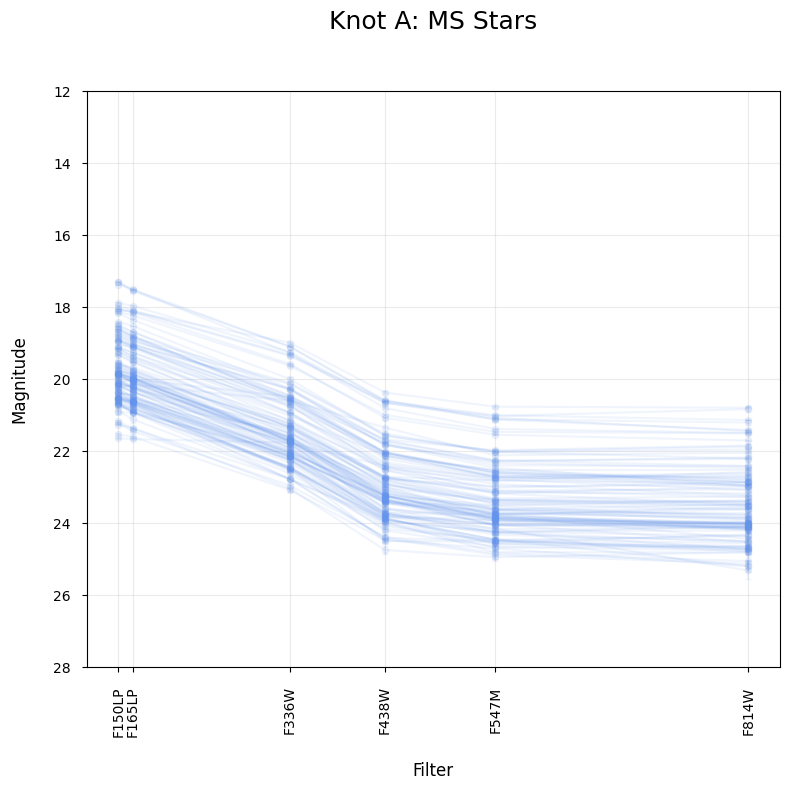

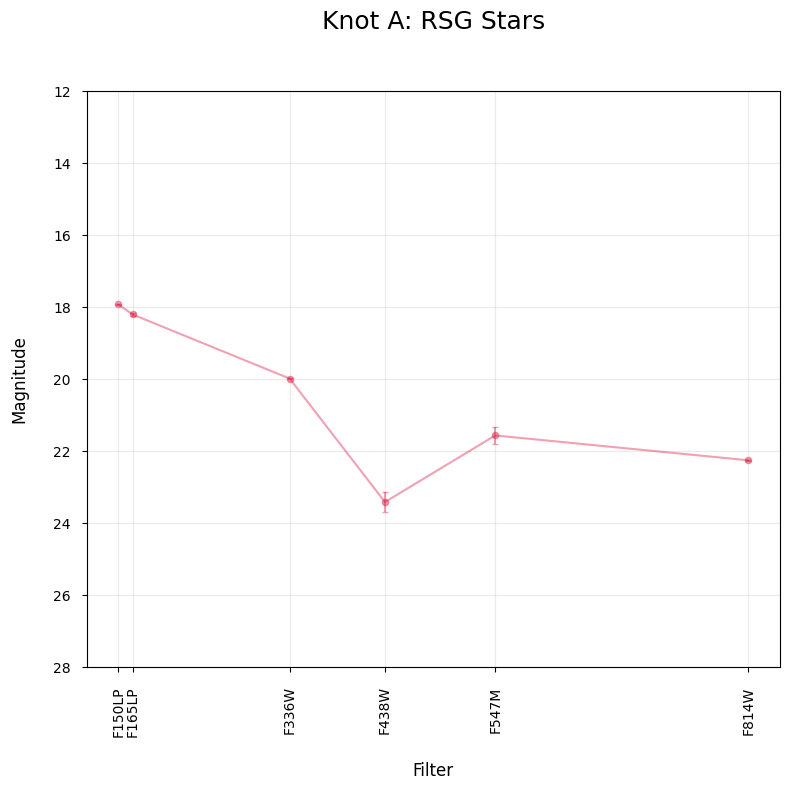

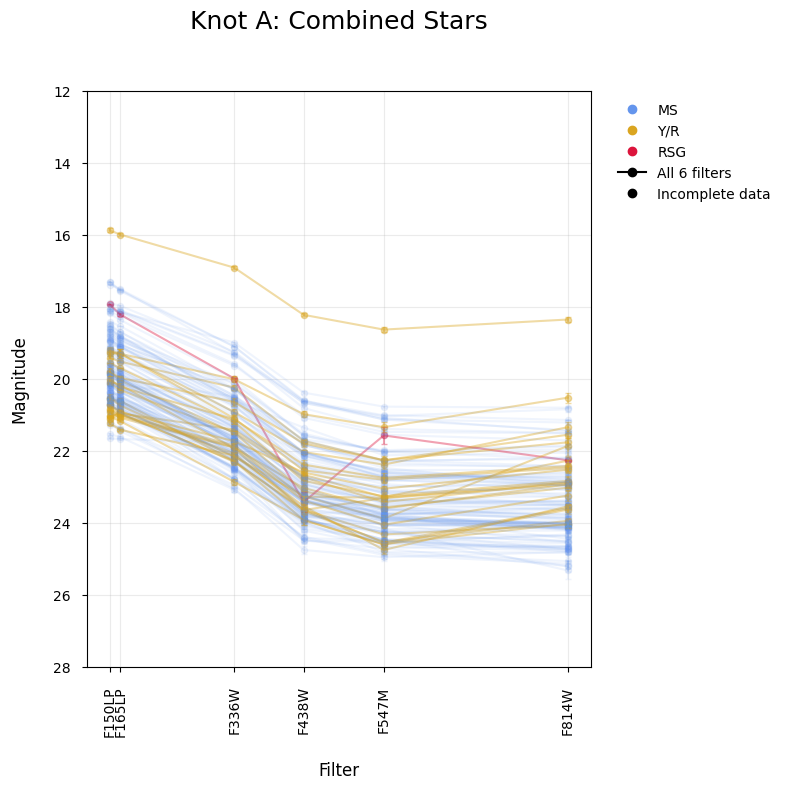

In [ ]:
# KNOT A — all available data
plot_sed(knotA_YR, "Knot A (all stars)", "Y/R", "KnotA_YR_all_data.png")
plot_sed(knotA_MS, "Knot A (all stars)", "MS", "KnotA_MS_all_data.png")
plot_sed(knotA_RSG, "Knot A (all stars)", "RSG", "KnotA_RSG_all_data.png")
plot_sed(knotA, "Knot A (all stars)", "Combined", "KnotA_combined_all_data.png")

# KNOT A — complete non-six-filter| data
plot_sed(knotA_six_YR, "Knot A", "Y/R", "KnotA_YR_six_filters.png")
plot_sed(knotA_six_MS, "Knot A", "MS", "KnotA_MS_six_filters.png")
plot_sed(knotA_six_RSG, "Knot A", "RSG", "KnotA_RSG_six_filters.png")
plot_sed(knotA_six, "Knot A", "Combined", "KnotA_combined_six_filters.png")

## ★ KNOT B

In [ ]:
knotB = prepare_table(knotB_path, "Knot B")
knotB_raw, knotB, knotB_six = knotB

# All available-data stars
knotB_YR, knotB_MS, knotB_RSG = separate_star_types(knotB)
# Complete six-filter stars
knotB_six_YR, knotB_six_MS, knotB_six_RSG = separate_star_types(knotB_six)

# Optional: display information about table edits and new tables
display_stats(
    knotB_raw,
    knotB,
    knotB_six,
    knotB_YR,
    knotB_MS,
    knotB_RSG,
    knotB_six_YR,
    knotB_six_MS,
    knotB_six_RSG,
)

Raw Table:


,Unnamed: 0,Label,x,y,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,3,MS,194.117911,12.670699,20.290284,0.009601,20.499369,0.025293,21.830010,0.032907,23.383009,0.031124,23.859477,0.042815,24.042169,0.079023
1,4,Y/R,115.647224,21.818368,21.191041,0.040553,21.300031,0.049886,22.543504,0.031315,24.104523,0.036322,24.732393,0.108316,24.301310,0.055172
2,5,MS,176.849282,22.100124,21.623675,0.019875,NaN,NaN,22.978520,0.046482,24.076417,0.074991,24.602559,0.059675,NaN,NaN
3,6,MS,167.796366,29.237551,21.989575,0.015167,NaN,NaN,22.716181,0.048306,23.916671,0.091236,24.216669,0.064465,24.085957,0.049594
4,8,MS,110.150935,31.497205,21.351690,0.014316,NaN,NaN,22.852040,0.055914,24.439909,0.097072,24.639700,0.076375,24.516572,0.092988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,367,Y/R,191.410476,211.647189,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.317077,0.068387,23.632704,0.055941
251,369,Y/R,18.493635,225.079540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.507614,0.048145,22.819650,0.021087
252,370,Y/R,46.078451,229.702519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.291478,0.057431,23.581016,0.008712
253,371,Y/R,69.957263,235.254308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.622571,0.055155,21.919866,0.006497


Clean Table — All Available Data:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,MS,20.29,0.01,20.5,0.03,21.83,0.03,23.38,0.03,23.86,0.04,24.04,0.08
1,Y/R,21.19,0.04,21.3,0.05,22.54,0.03,24.10,0.04,24.73,0.11,24.30,0.06
2,MS,21.62,0.02,NaN,NaN,22.98,0.05,24.08,0.07,24.60,0.06,NaN,NaN
3,MS,21.99,0.02,NaN,NaN,22.72,0.05,23.92,0.09,24.22,0.06,24.09,0.05
4,MS,21.35,0.01,NaN,NaN,22.85,0.06,24.44,0.10,24.64,0.08,24.52,0.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.32,0.07,23.63,0.06
251,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.51,0.05,22.82,0.02
252,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.29,0.06,23.58,0.01
253,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.62,0.06,21.92,0.01


Clean Table (only displaying stars with ALL six filters):


...

,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,MS,20.29,0.01,20.50,0.03,21.83,0.03,23.38,0.03,23.86,0.04,24.04,0.08
7,MS,19.84,0.01,19.91,0.01,20.87,0.02,22.31,0.03,22.71,0.04,22.74,0.04
9,MS,20.53,0.01,20.57,0.01,22.01,0.03,23.45,0.03,23.81,0.05,23.99,0.04
10,MS,18.45,0.02,18.48,0.02,19.23,0.01,20.73,0.03,21.11,0.02,21.11,0.03
11,MS,20.65,0.01,20.75,0.02,22.16,0.05,23.71,0.08,24.18,0.07,24.27,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,MS,19.82,0.01,20.01,0.03,21.60,0.02,23.39,0.19,23.61,0.08,23.81,0.05
157,MS,19.87,0.01,19.95,0.01,21.38,0.02,23.04,0.04,23.57,0.04,23.46,0.05
158,MS,20.37,0.02,20.53,0.02,22.17,0.08,23.45,0.10,23.84,0.03,23.81,0.06
161,MS,19.96,0.09,20.15,0.08,21.66,0.06,23.15,0.08,23.48,0.08,23.86,0.09


Clean RSG Stars:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err


Clean YR Stars:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
1,Y/R,21.19,0.04,21.30,0.05,22.54,0.03,24.10,0.04,24.73,0.11,24.30,0.06
21,Y/R,19.38,0.06,19.54,0.05,21.02,0.06,22.44,0.06,22.83,0.06,22.57,0.09
58,Y/R,20.52,0.04,20.57,0.03,21.78,0.10,22.88,0.12,23.30,0.15,23.02,0.13
113,Y/R,19.89,0.01,19.97,0.02,21.46,0.03,22.92,0.04,23.23,0.03,22.91,0.03
130,Y/R,20.87,0.09,21.02,0.12,22.58,0.09,23.65,0.05,24.17,0.13,23.87,0.07


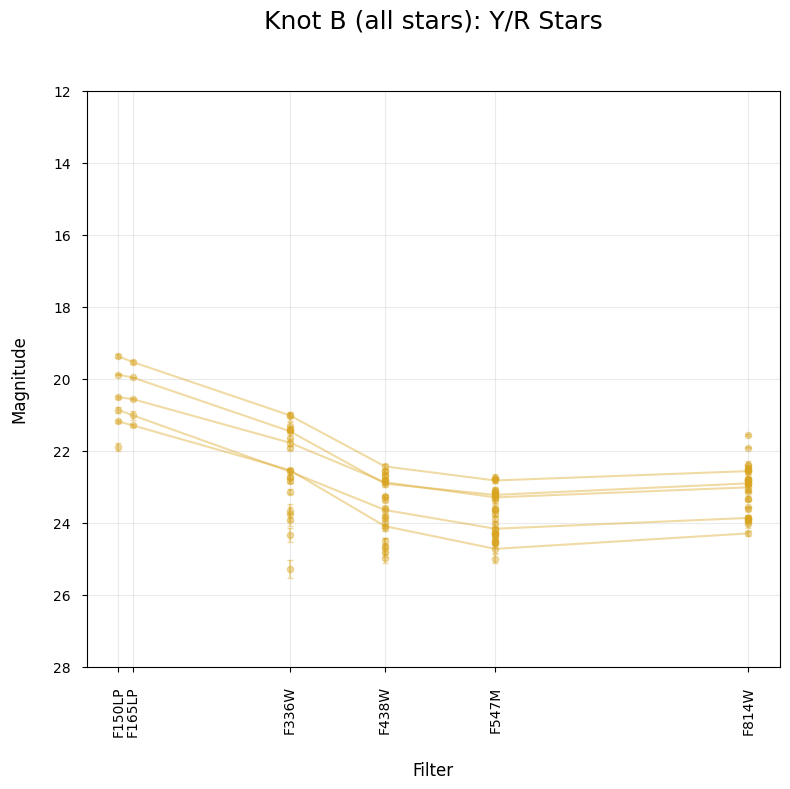

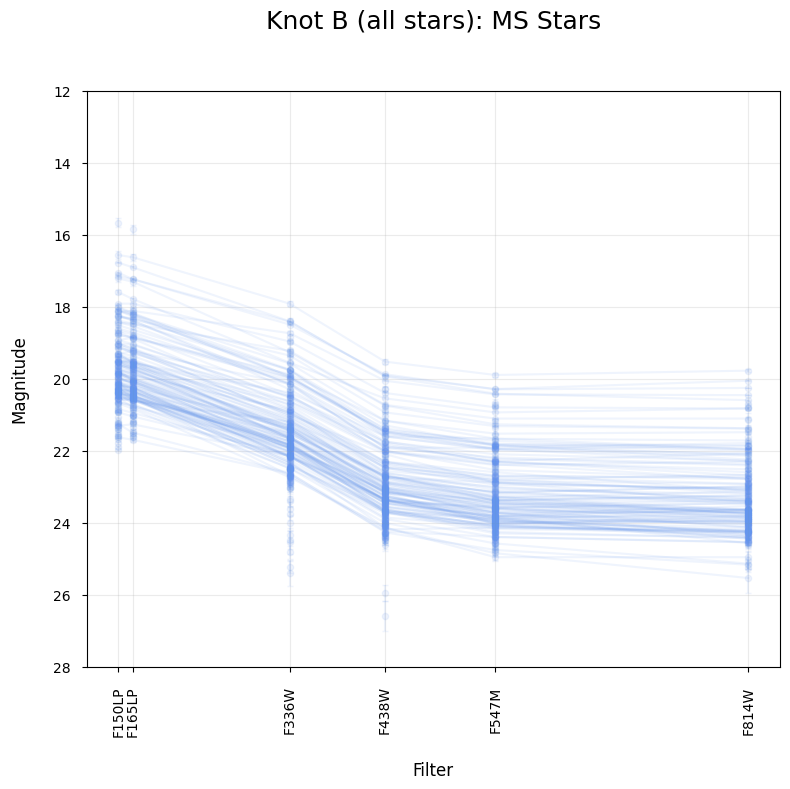

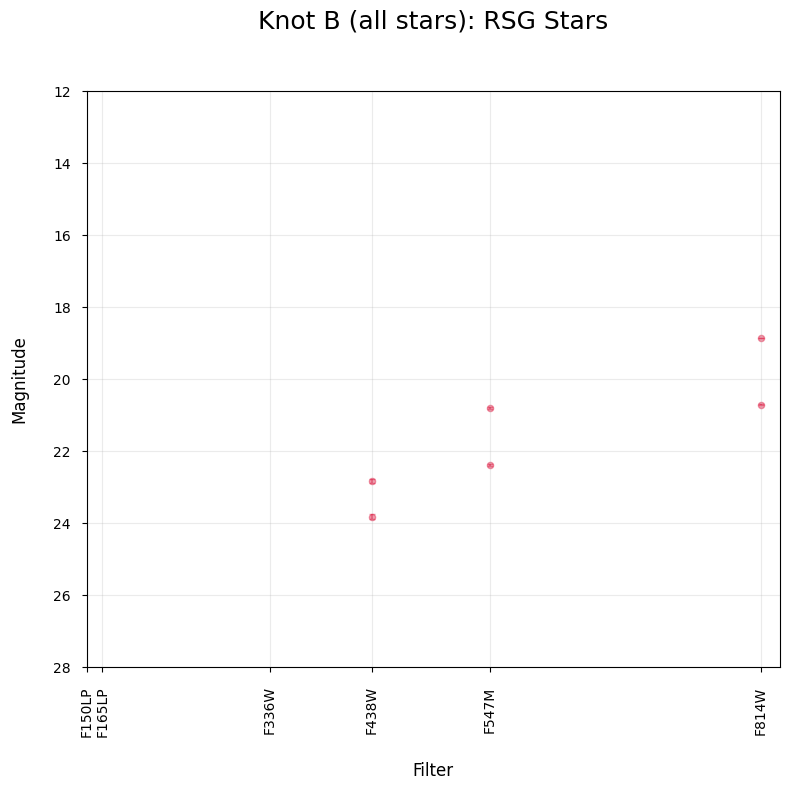

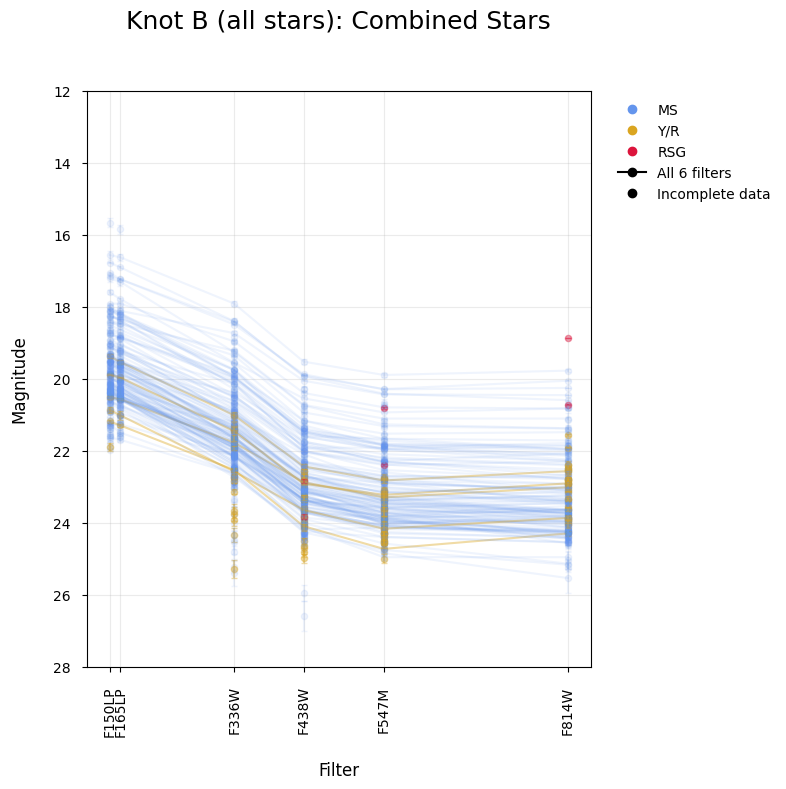

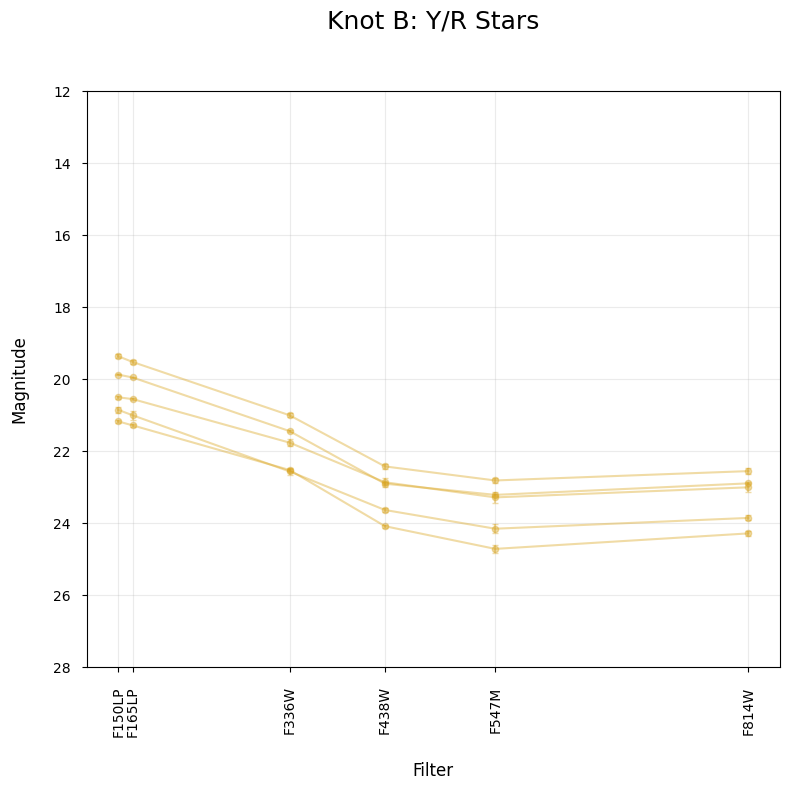

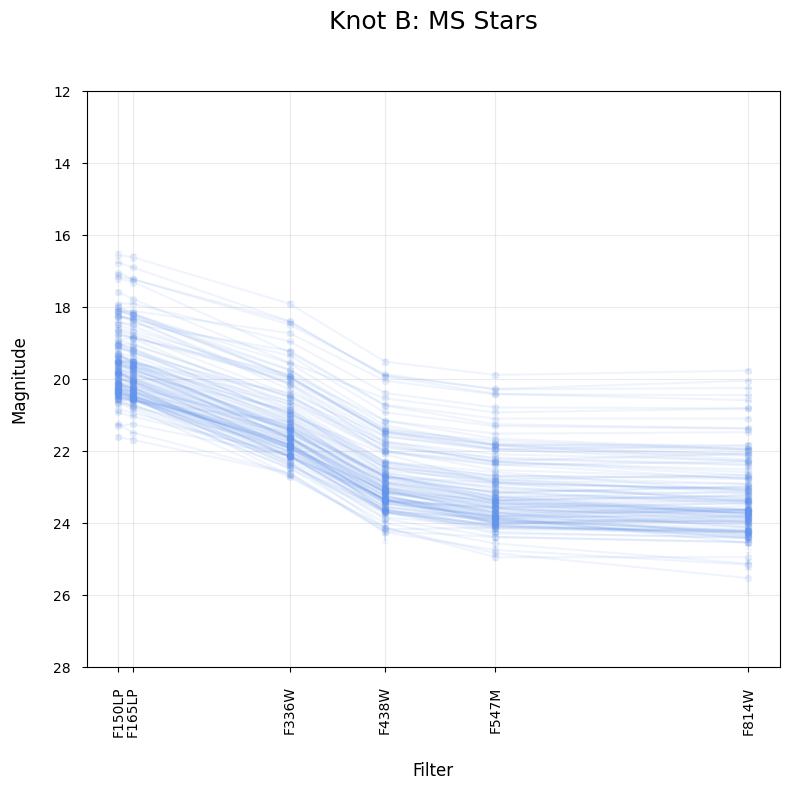

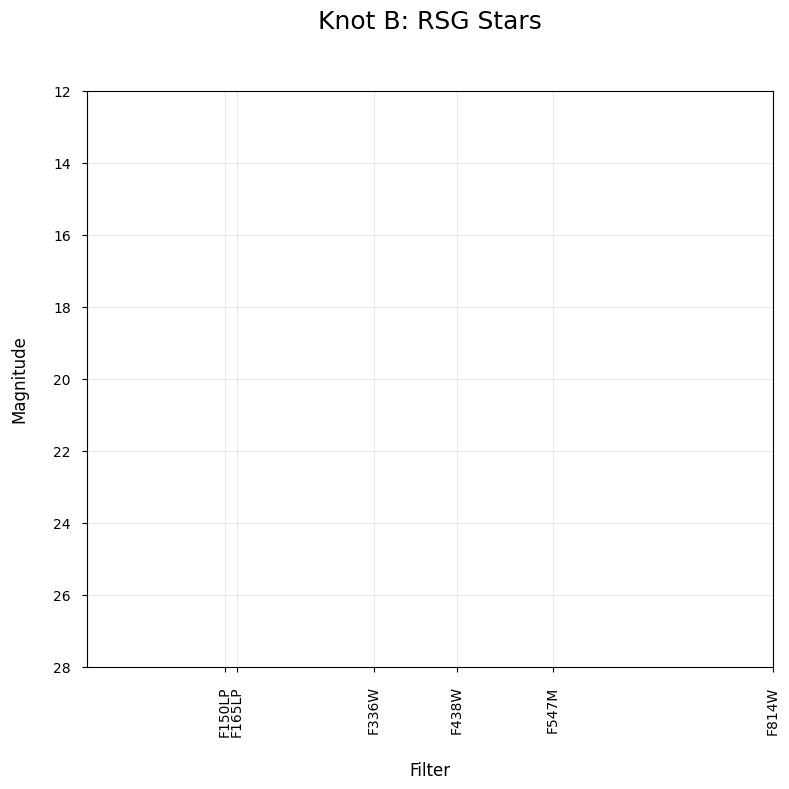

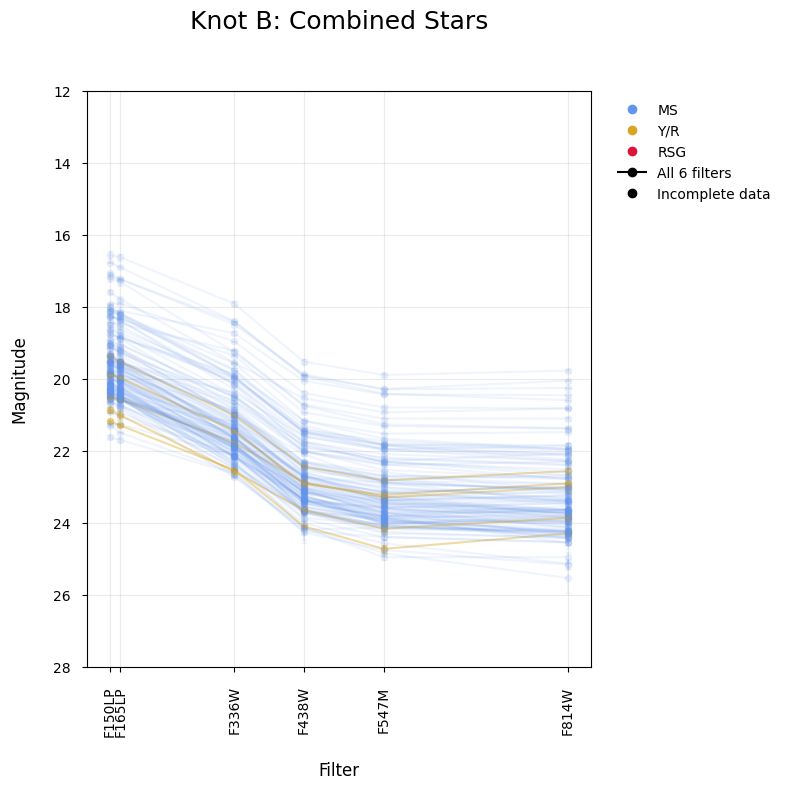

In [ ]:
# KNOT B — all available data
plot_sed(knotB_YR, "Knot B (all stars)", "Y/R", "KnotB_YR_all_data.png")
plot_sed(knotB_MS, "Knot B (all stars)", "MS", "KnotB_MS_all_data.png")
plot_sed(knotB_RSG, "Knot B (all stars)", "RSG", "KnotB_RSG_all_data.png")
plot_sed(knotB, "Knot B (all stars)", "Combined", "KnotB_combined_all_data.png")

# KNOT B — complete six-filter data
plot_sed(knotB_six_YR, "Knot B", "Y/R", "KnotB_YR_six_filters.png")
plot_sed(knotB_six_MS, "Knot B", "MS", "KnotB_MS_six_filters.png")
plot_sed(knotB_six_RSG, "Knot B", "RSG", "KnotB_RSG_six_filters.png")
plot_sed(knotB_six, "Knot B", "Combined", "KnotB_combined_six_filters.png")

## ★ REGION ii

In [ ]:
# REGION II — prepare tables
regionII_raw, regionII, regionII_six = prepare_table(regionII_path,"Region II")

# All available-data stars
regionII_YR, regionII_MS, regionII_RSG = separate_star_types(regionII)
# Complete six-filter stars
regionII_six_YR, regionII_six_MS, regionII_six_RSG = (separate_star_types(regionII_six))

# Optional statistics
display_stats(
    regionII_raw,
    regionII,
    regionII_six,
    regionII_YR,
    regionII_MS,
    regionII_RSG,
    regionII_six_YR,
    regionII_six_MS,
    regionII_six_RSG,
)

Raw Table:


,Unnamed: 0,Label,x,y,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,0,Y/R,314.745522,4.102459,20.567927,0.017474,20.700528,0.031894,21.514108,0.025079,23.047566,0.026124,23.137184,0.031693,22.763411,0.028511
1,1,MS,225.628139,8.572717,NaN,NaN,NaN,NaN,23.212670,0.078551,24.273936,0.043530,NaN,NaN,NaN,NaN
2,3,MS,286.451060,18.014136,20.705548,0.014922,20.903250,0.021701,22.185802,0.038543,24.110360,0.061823,24.351038,0.050103,NaN,NaN
3,7,MS,90.917524,35.996897,20.400205,0.088615,NaN,NaN,22.441837,0.074366,23.516678,0.067232,24.186405,0.079775,24.159969,0.033746
4,9,MS,256.636888,38.554972,21.107504,0.060134,21.210398,0.020318,22.491970,0.061337,24.057690,0.078633,24.088808,0.055012,24.408564,0.076203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,820,Y/R,86.504506,325.310091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.997182,0.107014,23.169798,0.033625
450,821,Y/R,384.228804,331.568921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.952048,0.127893,23.518784,0.039010
451,822,Y/R,325.138566,352.422179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.977803,0.122263,23.362898,0.038342
452,838,Y/R,16.682720,228.956472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.571194,0.076853,23.879241,0.033177


Clean Table — All Available Data:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,Y/R,20.57,0.02,20.70,0.03,21.51,0.03,23.05,0.03,23.14,0.03,22.76,0.03
1,MS,NaN,NaN,NaN,NaN,23.21,0.08,24.27,0.04,NaN,NaN,NaN,NaN
2,MS,20.71,0.01,20.90,0.02,22.19,0.04,24.11,0.06,24.35,0.05,NaN,NaN
3,MS,20.40,0.09,NaN,NaN,22.44,0.07,23.52,0.07,24.19,0.08,24.16,0.03
4,MS,21.11,0.06,21.21,0.02,22.49,0.06,24.06,0.08,24.09,0.06,24.41,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.00,0.11,23.17,0.03
450,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.95,0.13,23.52,0.04
451,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.98,0.12,23.36,0.04
452,Y/R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.57,0.08,23.88,0.03


Clean Table (only displaying stars with ALL six filters):


...

,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
4,MS,21.11,0.06,21.21,0.02,22.49,0.06,24.06,0.08,24.09,0.06,24.41,0.08
5,MS,19.13,0.01,19.21,0.01,20.46,0.02,22.03,0.03,22.38,0.02,22.56,0.02
6,MS,20.08,0.01,20.17,0.02,21.20,0.02,22.73,0.02,23.18,0.03,23.26,0.03
7,MS,21.02,0.02,20.99,0.02,21.59,0.03,22.65,0.05,22.91,0.04,23.03,0.03
8,MS,20.71,0.02,20.69,0.04,22.05,0.05,23.46,0.05,23.91,0.06,24.05,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,MS,20.36,0.03,20.63,0.10,21.94,0.04,23.38,0.04,23.88,0.06,24.18,0.08
251,MS,20.97,0.01,21.08,0.02,22.24,0.07,23.74,0.05,23.99,0.11,23.80,0.07
252,MS,20.05,0.02,20.18,0.01,21.70,0.04,23.46,0.04,23.79,0.06,24.05,0.05
253,MS,20.05,0.02,20.09,0.05,21.78,0.06,23.29,0.06,23.79,0.09,23.99,0.06


Clean RSG Stars:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err


Clean YR Stars:


,Label,F150LP,F150LP_mags_err,F165LP,F165LP_mags_err,F336W,F336W_mags_err,F438W,F438W_mags_err,F547M,F547M_mags_err,F814W,F814W_mags_err
0,Y/R,20.57,0.02,20.70,0.03,21.51,0.03,23.05,0.03,23.14,0.03,22.76,0.03
31,Y/R,19.49,0.06,19.62,0.03,21.33,0.04,22.82,0.03,23.90,0.14,23.09,0.06
49,Y/R,21.11,0.01,21.08,0.03,22.91,0.07,23.99,0.06,24.71,0.12,24.35,0.04
50,Y/R,19.94,0.02,19.92,0.01,20.56,0.01,21.65,0.03,21.17,0.02,19.81,0.02
57,Y/R,20.17,0.09,20.32,0.08,21.85,0.05,23.33,0.07,23.06,0.10,22.32,0.03
61,Y/R,20.35,0.02,20.59,0.02,22.08,0.02,23.37,0.10,23.70,0.09,23.16,0.04
79,Y/R,21.39,0.01,21.51,0.02,22.93,0.04,24.22,0.07,24.61,0.10,24.30,0.07
88,Y/R,18.99,0.01,18.95,0.01,18.47,0.01,19.56,0.03,19.70,0.02,19.38,0.01
102,Y/R,21.23,0.10,21.38,0.09,22.61,0.04,23.97,0.08,24.44,0.09,24.05,0.03
122,Y/R,20.60,0.07,20.66,0.07,22.50,0.10,23.53,0.07,24.01,0.08,22.96,0.05


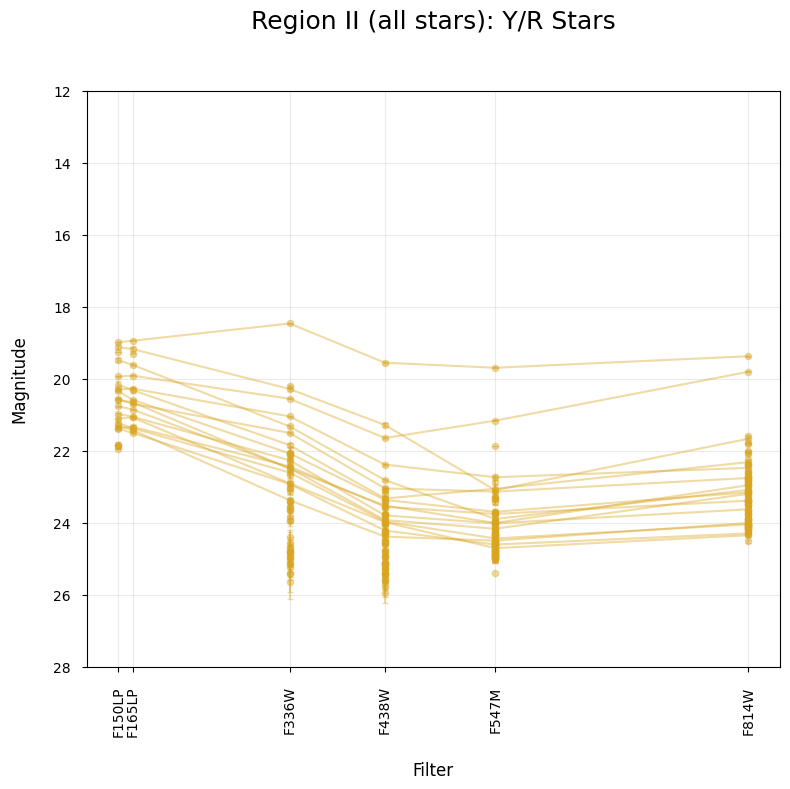

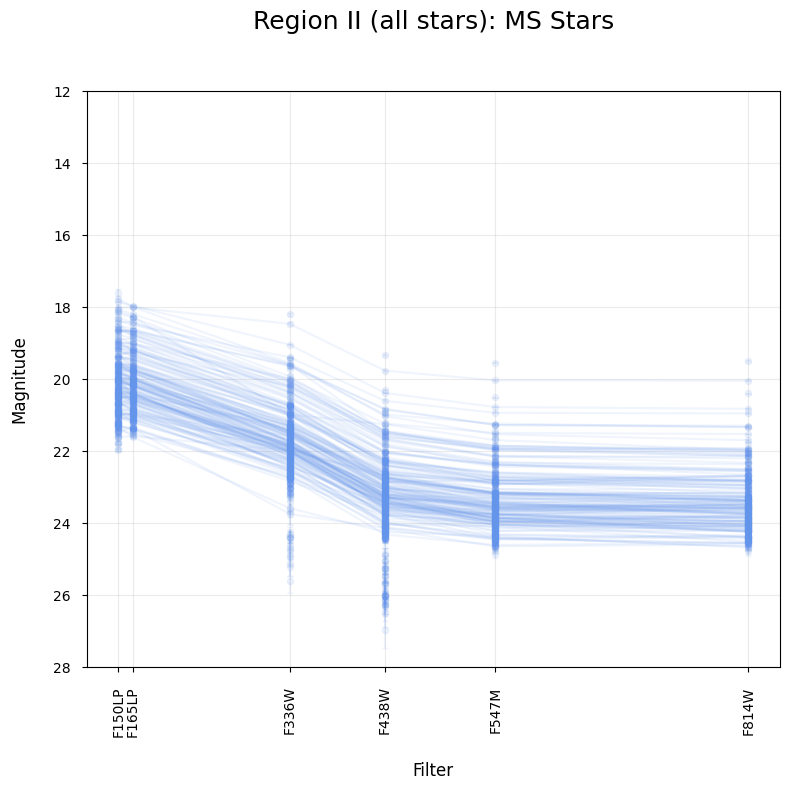

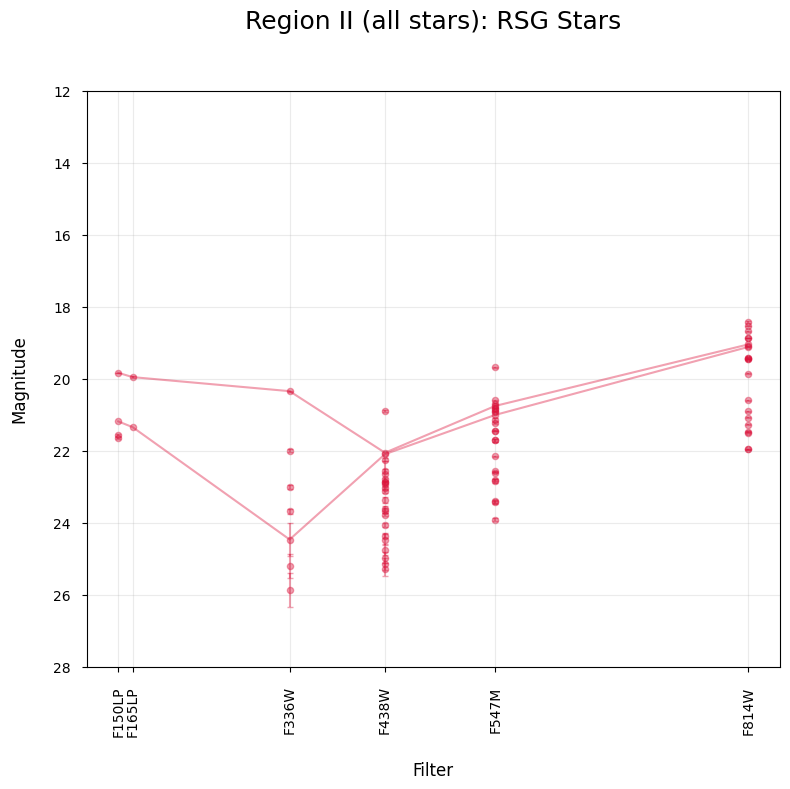

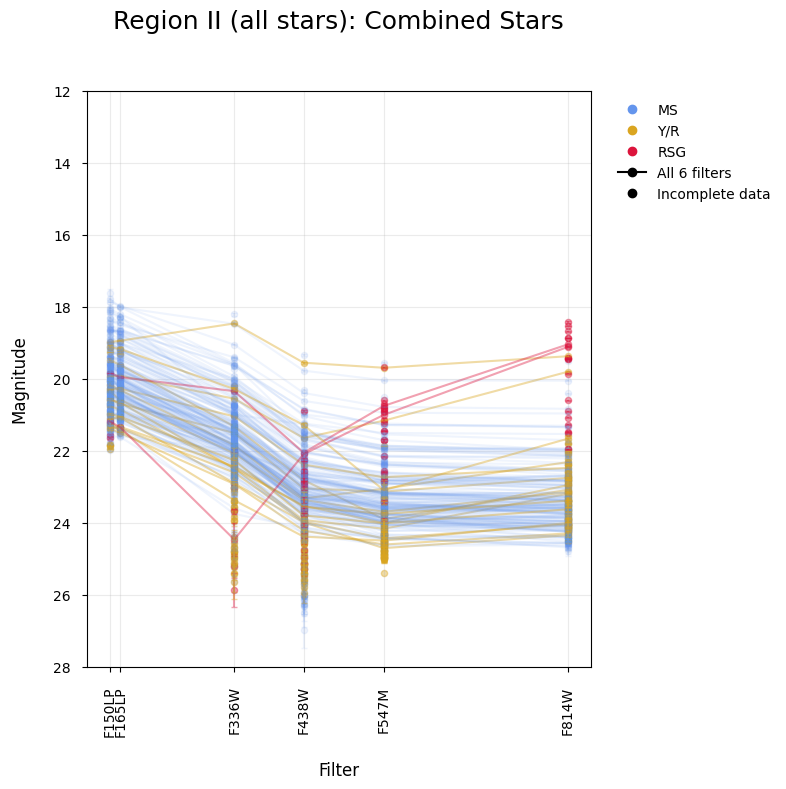

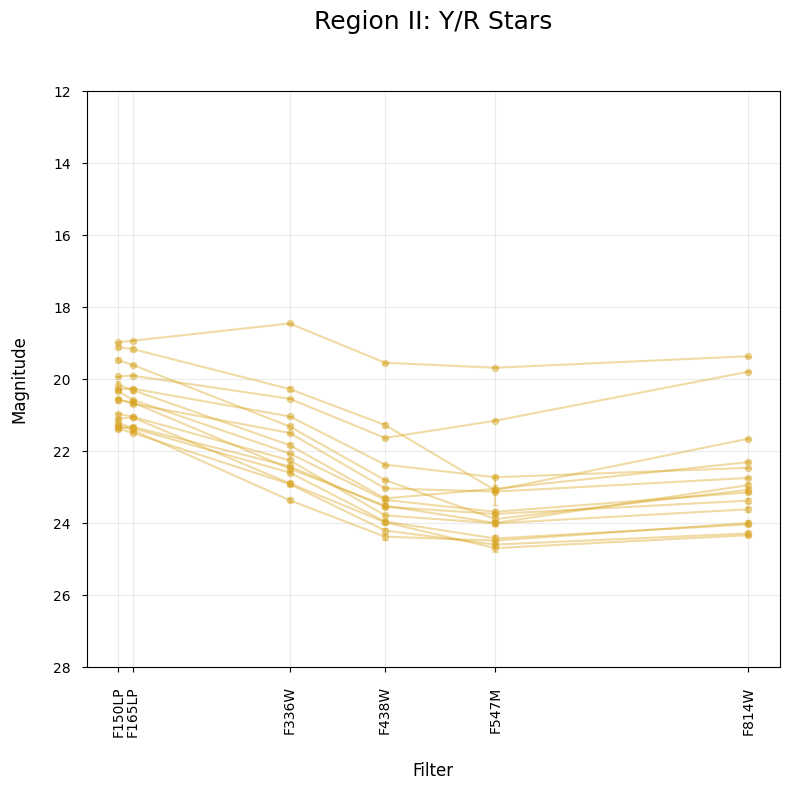

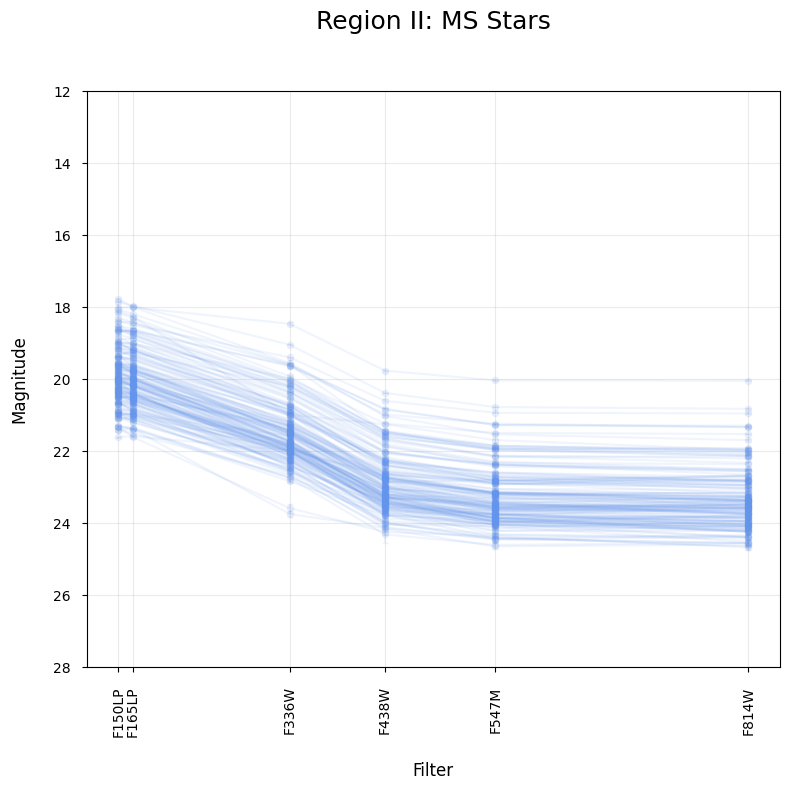

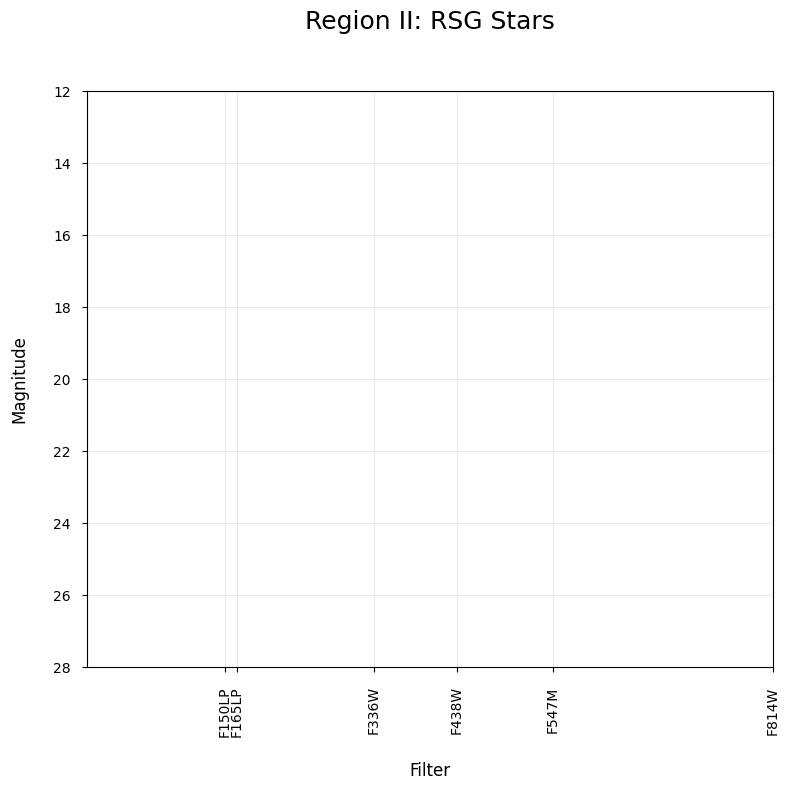

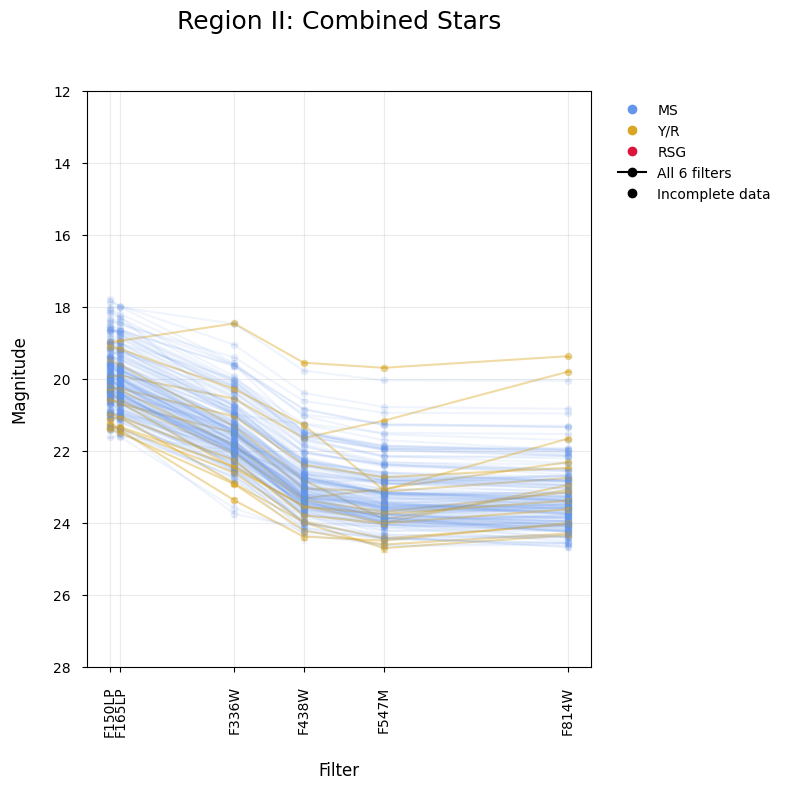

In [ ]:
# REGION II — all available data
plot_sed(regionII_YR, "Region II (all stars)", "Y/R", "RegionII_YR_all_data.png")
plot_sed(regionII_MS, "Region II (all stars)", "MS", "RegionII_MS_all_data.png")
plot_sed(regionII_RSG, "Region II (all stars)", "RSG", "RegionII_RSG_all_data.png")
plot_sed(regionII, "Region II (all stars)", "Combined", "RegionII_combined_all_data.png")

# REGION II — complete six-filter data
plot_sed(regionII_six_YR, "Region II", "Y/R", "RegionII_YR_six_filters.png")
plot_sed(regionII_six_MS, "Region II", "MS", "RegionII_MS_six_filters.png")
plot_sed(regionII_six_RSG, "Region II", "RSG", "RegionII_RSG_six_filters.png")
plot_sed(regionII_six, "Region II", "Combined", "RegionII_combined_six_filters.png")